In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading the dataset
df =pd.read_excel('/content/Unicorn_Companies.xlsx')

In [3]:
df.head()

,Company,Valuation,Date Joined,Industry,City,Country,Continent,Year Founded,Funding,Select Investors
0,Bytedance,$180B,2017-04-07,Artificial intelligence,Beijing,China,Asia,2012,$8B,"Sequoia Capital China, SIG Asia Investments, S..."
1,SpaceX,$100B,2012-12-01,Other,Hawthorne,United States,North America,2002,$7B,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
2,SHEIN,$100B,2018-07-03,E-commerce & direct-to-consumer,Shenzhen,China,Asia,2008,$2B,"Tiger Global Management, Sequoia Capital China..."
3,Stripe,$95B,2014-01-23,Fintech,San Francisco,United States,North America,2010,$2B,"Khosla Ventures, LowercaseCapital, capitalG"
4,Klarna,$46B,2011-12-12,Fintech,Stockholm,Sweden,Europe,2005,$4B,"Institutional Venture Partners, Sequoia Capita..."


In [4]:
df.tail()

,Company,Valuation,Date Joined,Industry,City,Country,Continent,Year Founded,Funding,Select Investors
1069,Zhaogang,$1B,2017-06-29,E-commerce & direct-to-consumer,Shanghai,China,Asia,2012,$379M,"K2 Ventures, Matrix Partners China, IDG Capital"
1070,Zhuan Zhuan,$1B,2017-04-18,E-commerce & direct-to-consumer,Beijing,China,Asia,2015,$990M,"58.com, Tencent Holdings"
1071,Zihaiguo,$1B,2021-05-06,Consumer & retail,Chongqing,China,Asia,2018,$80M,"Xingwang Investment Management, China Capital ..."
1072,Zopa,$1B,2021-10-19,Fintech,London,United Kingdom,Europe,2005,$792M,"IAG Capital Partners, Augmentum Fintech, North..."
1073,Zwift,$1B,2020-09-16,E-commerce & direct-to-consumer,Long Beach,United States,North America,2014,$620M,"Novator Partners, True, Causeway Media Partners"


In [5]:
df.shape

(1074, 10)

In [6]:
df.columns

Index(['Company', 'Valuation', 'Date Joined', 'Industry', 'City', 'Country',
       'Continent', 'Year Founded', 'Funding', 'Select Investors'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1074 entries, 0 to 1073
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Company           1074 non-null   object        
 1   Valuation         1074 non-null   object        
 2   Date Joined       1074 non-null   datetime64[ns]
 3   Industry          1074 non-null   object        
 4   City              1058 non-null   object        
 5   Country           1074 non-null   object        
 6   Continent         1074 non-null   object        
 7   Year Founded      1074 non-null   int64         
 8   Funding           1074 non-null   object        
 9   Select Investors  1073 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(8)
memory usage: 84.0+ KB


In [8]:
df.describe()

,Date Joined,Year Founded
count,1074,1074.000000
mean,2020-05-19 15:35:51.955307264,2012.895717
min,2007-07-02 00:00:00,1919.000000
25%,2019-05-20 06:00:00,2011.000000
50%,2021-03-29 00:00:00,2014.000000
75%,2021-09-19 18:00:00,2016.000000
max,2022-04-05 00:00:00,2021.000000
std,NaN,5.698573


In [9]:
df.isnull().sum()

,0
Company,0
Valuation,0
Date Joined,0
Industry,0
City,16
Country,0
Continent,0
Year Founded,0
Funding,0
Select Investors,1


In [10]:
df.isnull().mean()* 100

,0
Company,0.000000
Valuation,0.000000
Date Joined,0.000000
Industry,0.000000
City,1.489758
Country,0.000000
Continent,0.000000
Year Founded,0.000000
Funding,0.000000
Select Investors,0.093110


In [11]:
df['City'] = df['City'].fillna('Unknown')

In [12]:
def convert_to_billions(value):

    if pd.isna(value):
        return None
    value = str(value).replace('$', '').strip()

    if value.endswith('B'):
        return float(value[:-1])

    elif value.endswith('M'):
        return float(value[:-1]) / 1000

    return None

In [13]:
# Applying function to entire column
df['Valuation_B'] = df['Valuation'].apply(convert_to_billions)

In [14]:
df['Funding_B'] = df['Funding'].apply(convert_to_billions)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1074 entries, 0 to 1073
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Company           1074 non-null   object        
 1   Valuation         1074 non-null   object        
 2   Date Joined       1074 non-null   datetime64[ns]
 3   Industry          1074 non-null   object        
 4   City              1074 non-null   object        
 5   Country           1074 non-null   object        
 6   Continent         1074 non-null   object        
 7   Year Founded      1074 non-null   int64         
 8   Funding           1074 non-null   object        
 9   Select Investors  1073 non-null   object        
 10  Valuation_B       1074 non-null   float64       
 11  Funding_B         1062 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(8)
memory usage: 100.8+ KB


In [16]:
df.isnull().sum()

,0
Company,0
Valuation,0
Date Joined,0
Industry,0
City,0
Country,0
Continent,0
Year Founded,0
Funding,0
Select Investors,1


In [17]:
industry_count = df['Industry'].value_counts().head(10)

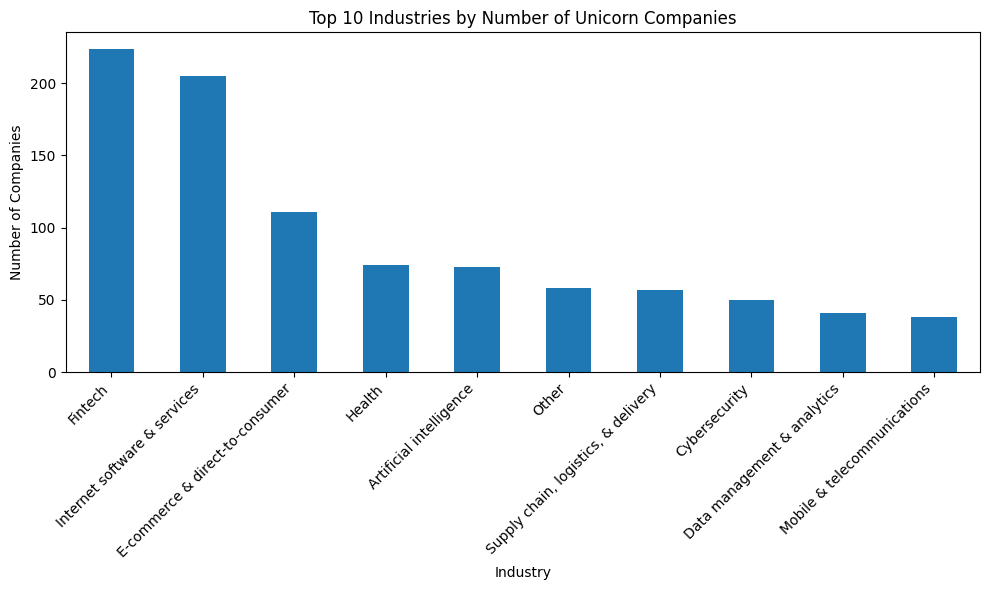

In [18]:
plt.figure(figsize=(10, 6))

industry_count.plot(kind='bar')

plt.title('Top 10 Industries by Number of Unicorn Companies')
plt.xlabel('Industry')
plt.ylabel('Number of Companies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

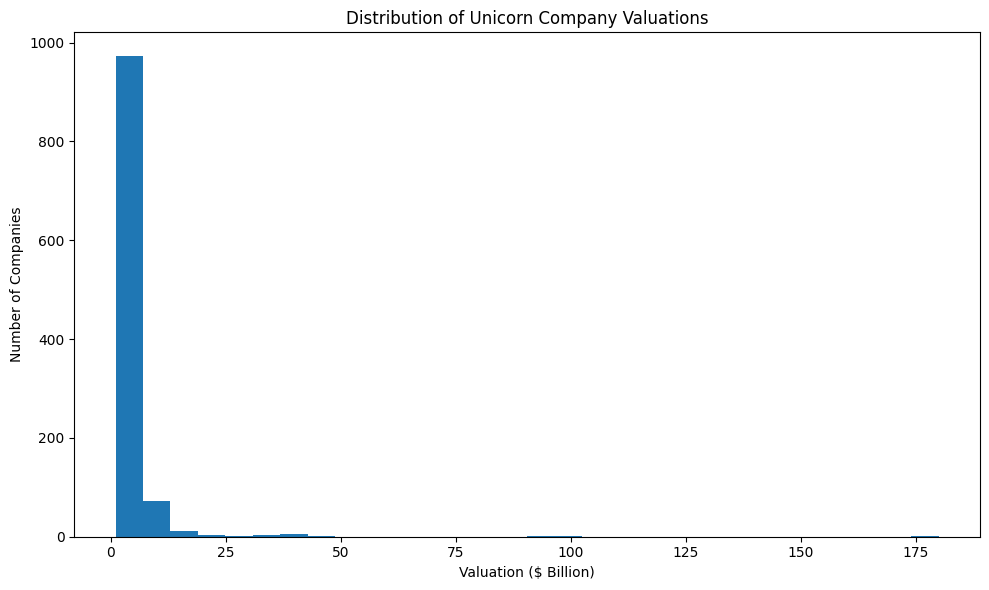

In [19]:
plt.figure(figsize=(10, 6))

plt.hist(
    df['Valuation_B'].dropna(),
    bins=30
)
plt.title('Distribution of Unicorn Company Valuations')
plt.xlabel('Valuation ($ Billion)')
plt.ylabel('Number of Companies')

plt.tight_layout()
plt.show()

In [20]:
plot_df = df.dropna(
    subset=['Funding_B', 'Valuation_B']
)

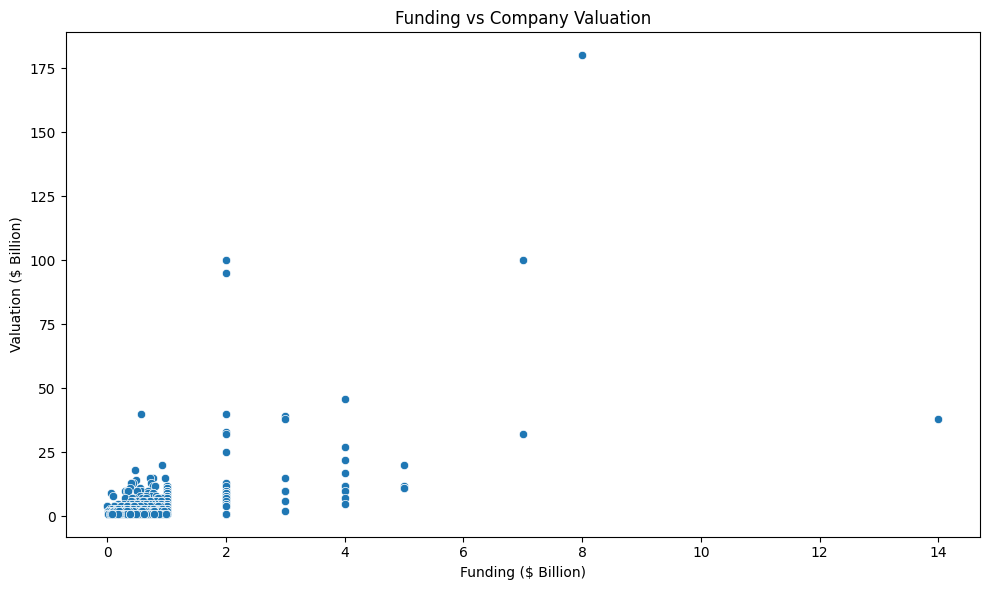

In [21]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_df,
    x='Funding_B',
    y='Valuation_B'
)
plt.title('Funding vs Company Valuation')
plt.xlabel('Funding ($ Billion)')
plt.ylabel('Valuation ($ Billion)')

plt.tight_layout()
plt.show()

In [22]:
top_industries = df['Industry'].value_counts().head(10).index

In [23]:
industry_valuation = (
    df[df['Industry'].isin(top_industries)]
    .groupby('Industry')['Valuation_B']
    .mean()
    .sort_values(ascending=False)
)

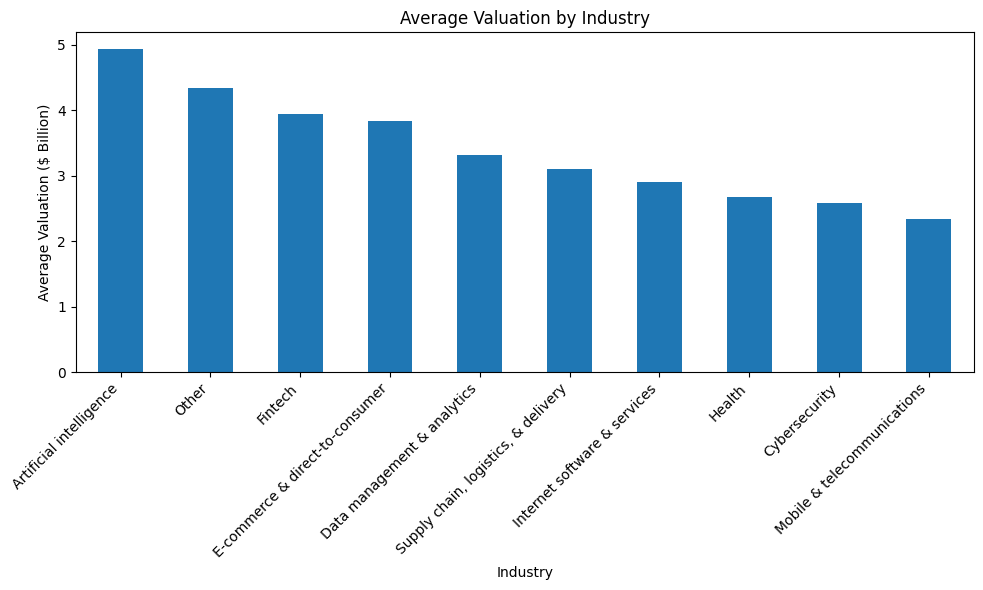

In [24]:
plt.figure(figsize=(10, 6))

industry_valuation.plot(kind='bar')

plt.title('Average Valuation by Industry')
plt.xlabel('Industry')
plt.ylabel('Average Valuation ($ Billion)')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

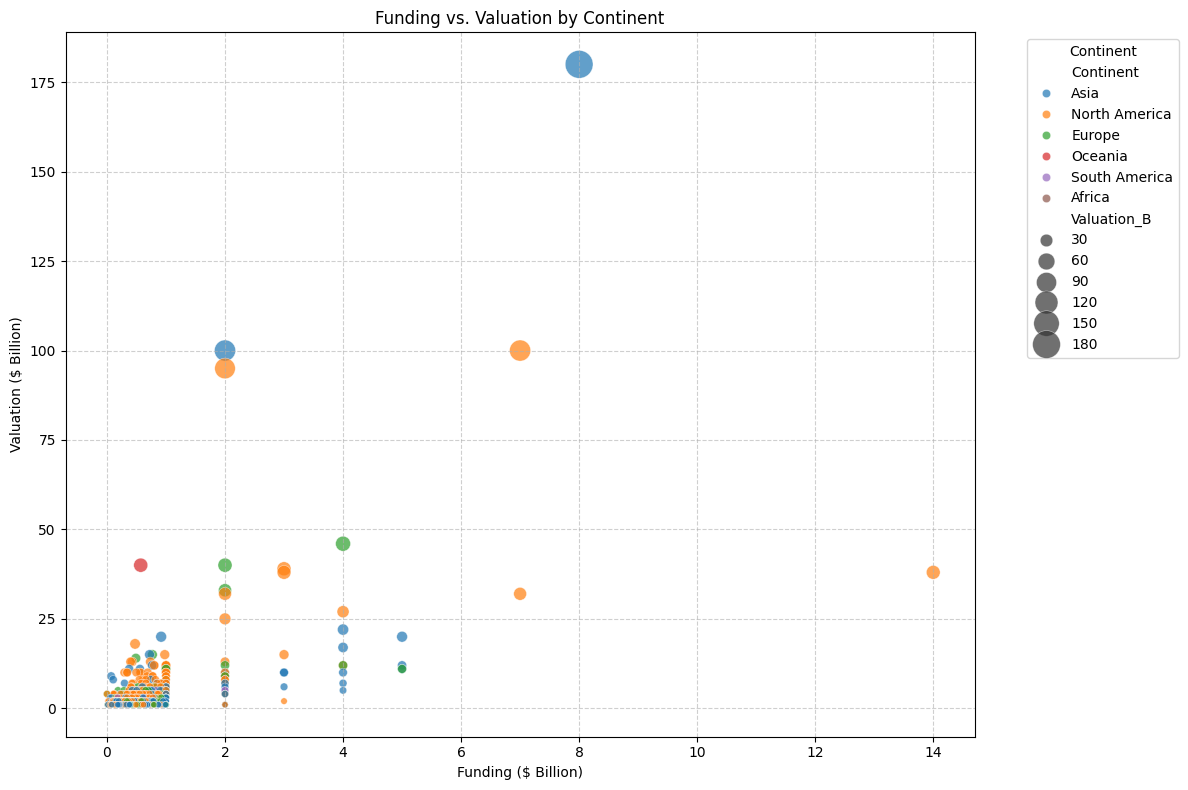

In [25]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=plot_df,
    x='Funding_B',
    y='Valuation_B',
    hue='Continent', # Use Continent for color differentiation
    size='Valuation_B', # Use Valuation_B for size differentiation
    sizes=(20, 400), # Adjust size range for better visualization
    alpha=0.7
)
plt.title('Funding vs. Valuation by Continent')
plt.xlabel('Funding ($ Billion)')
plt.ylabel('Valuation ($ Billion)')
plt.legend(title='Continent', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [26]:
correlation = plot_df['Funding_B'].corr(plot_df['Valuation_B'])
print(f"Correlation between Funding_B and Valuation_B: {correlation:.2f}")

Correlation between Funding_B and Valuation_B: 0.60
